In [ ]:
import kagglehub

path = kagglehub.dataset_download("shanks0465/braille-character-dataset")

print("Path to dataset files:", path)

100%|██████████| 1.30M/1.30M [00:01<00:00, 993kB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/shanks0465/braille-character-dataset/versions/1


✅ All libraries imported successfully!
📂 Images found in: /root/.cache/kagglehub/datasets/shanks0465/braille-character-dataset/versions/1/Braille Dataset/Braille Dataset
⏳ Loading and cleaning images...
✅ Loaded and cleaned 1560 images
📊 Unique classes: [np.str_('a'), np.str_('b'), np.str_('c'), np.str_('d'), np.str_('e'), np.str_('f'), np.str_('g'), np.str_('h'), np.str_('i'), np.str_('j'), np.str_('k'), np.str_('l'), np.str_('m'), np.str_('n'), np.str_('o'), np.str_('p'), np.str_('q'), np.str_('r'), np.str_('s'), np.str_('t'), np.str_('u'), np.str_('v'), np.str_('w'), np.str_('x'), np.str_('y'), np.str_('z')]


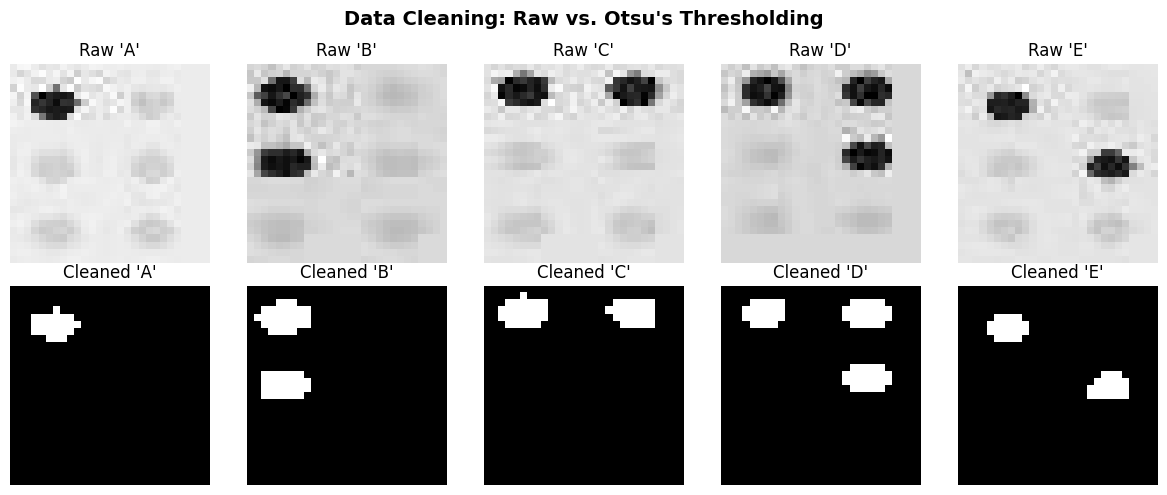

✅ Normalization done. Max value: 1.0, Min value: 0.0
⏳ Extracting HOG features...
✅ HOG extraction complete! Feature vector size: 1152
✅ Label encoding done. Total classes: 26
✅ Train/Test Split done (80/20)
✅ Standardization applied without data leakage.
✅ PCA applied (95% variance retained):
   Features reduced from 1152 → 139

  🚀 PREPROCESSING PIPELINE COMPLETE 🚀
  Total images processed      : 1560
  Final features per image    : 139
  Training set shape (X, y)   : (1248, 139), (1248,)
  Testing set shape  (X, y)   : (312, 139), (312,)
  Next Step: Pass X_train_pca and y_train to your 5 Models!


In [ ]:
# ─────────────────────────────────────────────────────────────
# STEP 0: Import Libraries
# ─────────────────────────────────────────────────────────────
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Image Processing
from skimage.feature import hog
from skimage.filters import threshold_otsu
from skimage import exposure

# Machine Learning & Preprocessing
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────────
# STEP 1: Set Dataset Path
# ─────────────────────────────────────────────────────────────
BASE_PATH = "/root/.cache/kagglehub/datasets/shanks0465/braille-character-dataset/versions/1"

# Automatically find the directory containing the images (to handle nested folders)
DATASET_PATH = None
for root, dirs, files in os.walk(BASE_PATH):
    if any(file.endswith(('.jpg', '.jpeg', '.png')) for file in files):
        DATASET_PATH = root
        break

if DATASET_PATH is None:
    raise FileNotFoundError("Could not find image files in the provided path.")

print(f" Images found in: {DATASET_PATH}")

# ─────────────────────────────────────────────────────────────
# STEP 2 & 2.5: Load Images + Image Cleaning (Otsu's Thresholding)
# ─────────────────────────────────────────────────────────────
IMG_SIZE = (28, 28)

raw_images = []
cleaned_images = []
labels = []

print("⏳ Loading and cleaning images...")
for filename in sorted(os.listdir(DATASET_PATH)):
    if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
        label = filename[0].lower()

        if label.isalpha():
            img_path = os.path.join(DATASET_PATH, filename)

            # 1. Load as Grayscale and Resize
            img_gray = np.array(Image.open(img_path).convert('L').resize(IMG_SIZE))

            # 2. Otsu's Thresholding to remove background and noise
            # Braille dots are usually dark on a lighter background.
            thresh_val = threshold_otsu(img_gray)
            # We invert it so dots become white (255) and background becomes black (0)
            img_clean = img_gray < thresh_val
            img_clean = (img_clean * 255).astype(np.uint8)

            raw_images.append(img_gray)
            cleaned_images.append(img_clean)
            labels.append(label)

raw_images = np.array(raw_images)
cleaned_images = np.array(cleaned_images)
labels = np.array(labels)

print(f"✅ Loaded and cleaned {len(cleaned_images)} images")
print(f"📊 Unique classes: {sorted(set(labels))}")

# ─────────────────────────────────────────────────────────────
# STEP 3: Visualize Raw vs. Cleaned Images
# ─────────────────────────────────────────────────────────────
unique_labels = sorted(set(labels))
# Plot 5 random classes to show the cleaning effect
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Data Cleaning: Raw vs. Otsu's Thresholding", fontsize=14, fontweight='bold')

for i in range(5):
    letter = unique_labels[i]
    idx = np.where(labels == letter)[0][0]

    # Top Row: Raw Images
    axes[0, i].imshow(raw_images[idx], cmap='gray')
    axes[0, i].set_title(f"Raw '{letter.upper()}'")
    axes[0, i].axis('off')

    # Bottom Row: Cleaned Images
    axes[1, i].imshow(cleaned_images[idx], cmap='gray')
    axes[1, i].set_title(f"Cleaned '{letter.upper()}'")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────
# STEP 4: Normalize Pixels to [0.0, 1.0]
# ─────────────────────────────────────────────────────────────
images_normalized = cleaned_images.astype(np.float32) / 255.0
print(f"✅ Normalization done. Max value: {images_normalized.max():.1f}, Min value: {images_normalized.min():.1f}")

# ─────────────────────────────────────────────────────────────
# STEP 5: HOG Feature Extraction
# ─────────────────────────────────────────────────────────────
HOG_PARAMS = {
    'orientations': 8,
    'pixels_per_cell': (4, 4),
    'cells_per_block': (2, 2),
    'visualize': False,
    'feature_vector': True
}

print("⏳ Extracting HOG features...")
X_hog = np.array([hog(img, **HOG_PARAMS) for img in images_normalized])
print(f"✅ HOG extraction complete! Feature vector size: {X_hog.shape[1]}")

# ─────────────────────────────────────────────────────────────
# STEP 6: Label Encoding
# ─────────────────────────────────────────────────────────────
le = LabelEncoder()
y_encoded = le.fit_transform(labels)
print(f"✅ Label encoding done. Total classes: {len(le.classes_)}")

# ─────────────────────────────────────────────────────────────
# STEP 7: Train/Test Split (CRITICAL: Must be done BEFORE Scaling/PCA)
# ─────────────────────────────────────────────────────────────
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_hog, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)
print(f"✅ Train/Test Split done (80/20)")

# ─────────────────────────────────────────────────────────────
# STEP 8: StandardScaler (Fit on Train, Transform Train & Test)
# ─────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)  # Only transform the test set!
print("✅ Standardization applied without data leakage.")

# ─────────────────────────────────────────────────────────────
# STEP 9: PCA — Dimensionality Reduction
# ─────────────────────────────────────────────────────────────
# scikit-learn allows passing a float to n_components to automatically keep that % of variance
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"✅ PCA applied (95% variance retained):")
print(f"   Features reduced from {X_train_scaled.shape[1]} → {X_train_pca.shape[1]}")

# ─────────────────────────────────────────────────────────────
# STEP 10: Final Pipeline Summary
# ─────────────────────────────────────────────────────────────
print("\n" + "="*55)
print("  🚀 PREPROCESSING PIPELINE COMPLETE 🚀")
print("="*55)
print(f"  Total images processed      : {len(labels)}")
print(f"  Final features per image    : {X_train_pca.shape[1]}")
print(f"  Training set shape (X, y)   : {X_train_pca.shape}, {y_train.shape}")
print(f"  Testing set shape  (X, y)   : {X_test_pca.shape}, {y_test.shape}")
print("="*55)
print("  Next Step: Pass X_train_pca and y_train to your 5 Models!")

⏳ Initializing the 5 Classical ML Models...
🚀 Starting Training and Evaluation (This might take a minute)...

🔄 Processing SVM (RBF)...
🔄 Processing KNN...
🔄 Processing Random Forest...
🔄 Processing Logistic Regression...
🔄 Processing Gaussian NB...

 🏆 FINAL MODEL COMPARISON REPORT 🏆
              Model  CV F1-Score (Train)  Accuracy  Precision  Recall  F1-Score (Test)  ROC-AUC
          SVM (RBF)               0.7621    0.8077     0.8104  0.8077           0.8028   0.9877
Logistic Regression               0.7158    0.7564     0.7664  0.7564           0.7518   0.9755
      Random Forest               0.6980    0.7500     0.7537  0.7500           0.7423   0.9628
                KNN               0.6042    0.6571     0.7101  0.6571           0.6560   0.9373
        Gaussian NB               0.5769    0.6506     0.7126  0.6506           0.6513   0.9417

🌟 Best Performing Model: SVM (RBF) (based on F1-Score) 🌟


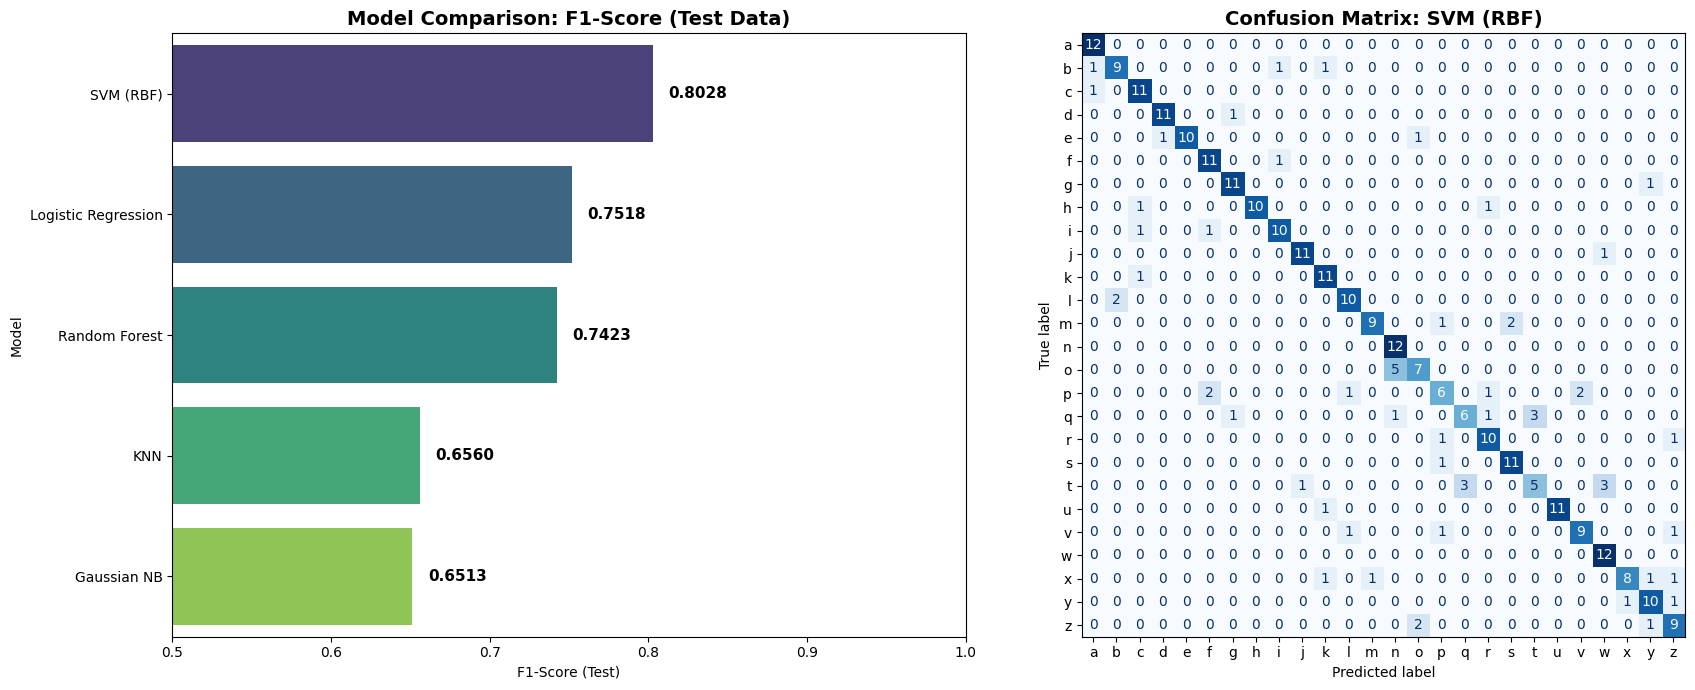


✅ Code Execution Finished! You can now use these results for your Final Report.


In [ ]:
# ============================================================
#  Braille-to-Text: Model Training & Evaluation
#  CS363 Machine Learning — Final Phase
# ============================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Import ML Models
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

# Import Evaluation Metrics
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)

print("⏳ Initializing the 5 Classical ML Models...")

# 1. Initialize the 5 Models
# We set probability=True for SVM to calculate ROC-AUC later
models = {
    "SVM (RBF)": SVC(kernel='rbf', probability=True, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Gaussian NB": GaussianNB()
}

results = []

# 2. Train and Evaluate Each Model
print("🚀 Starting Training and Evaluation (This might take a minute)...\n")

for name, model in models.items():
    print(f"🔄 Processing {name}...")

    # A. 5-Fold Cross Validation on Training Data
    cv_scores = cross_val_score(model, X_train_pca, y_train, cv=5, scoring='f1_weighted')
    cv_mean = cv_scores.mean()

    # B. Fit Model on full Training Data
    model.fit(X_train_pca, y_train)

    # C. Predict on Testing Data
    y_pred = model.predict(X_test_pca)
    y_prob = model.predict_proba(X_test_pca) # For ROC-AUC

    # D. Calculate Metrics (Weighted for Multi-class)
    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')

    # ROC-AUC (One-vs-Rest strategy for multi-class)
    roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')

    # E. Store Results
    results.append({
        "Model": name,
        "CV F1-Score (Train)": cv_mean,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1-Score (Test)": f1,
        "ROC-AUC": roc_auc
    })

# 3. Create a Comparison Table
results_df = pd.DataFrame(results)
# Sort by F1-Score (Test) descending to find the winner
results_df = results_df.sort_values(by="F1-Score (Test)", ascending=False).reset_index(drop=True)

print("\n" + "="*85)
print(" 🏆 FINAL MODEL COMPARISON REPORT 🏆")
print("="*85)
# Using pandas to print a nicely formatted table
print(results_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("="*85)

# 4. Identify the Best Model
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]
print(f"\n🌟 Best Performing Model: {best_model_name} (based on F1-Score) 🌟")

# 5. Visualizations
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot A: F1-Score Comparison Bar Chart
sns.barplot(x="F1-Score (Test)", y="Model", data=results_df, ax=axes[0], palette="viridis")
axes[0].set_title("Model Comparison: F1-Score (Test Data)", fontweight='bold', fontsize=14)
axes[0].set_xlim(0.5, 1.0) # Zoom in for better comparison
for i, v in enumerate(results_df["F1-Score (Test)"]):
    axes[0].text(v + 0.01, i, f"{v:.4f}", va='center', fontsize=11, fontweight='bold')

# Plot B: Confusion Matrix for the BEST Model
y_pred_best = best_model.predict(X_test_pca)
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', ax=axes[1], colorbar=False)
axes[1].set_title(f"Confusion Matrix: {best_model_name}", fontweight='bold', fontsize=14)

plt.tight_layout()
plt.savefig('model_evaluation_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Code Execution Finished! You can now use these results for your Final Report.")